# 🔍 Implémentation BioBERT - Modèle Transformer Pré-entraîné

Ce notebook implémente notre modèle **BioBERT** (modèle Transformer pré-entraîné sur des textes biomédicaux) pour la recherche d'information sur le dataset TREC-COVID.

## Objectifs
- Charger le dataset TREC-COVID
- Charger un modèle BERT pré-entraîné sur des textes biomédicaux (BioBERT)
- Utiliser les embeddings contextuels via le token [CLS]
- Utiliser les fonctions généralistes pour la recherche et l'évaluation
- Évaluer les performances avec NDCG@10 et comparer avec BioWord2Vec et TF-IDF


## 📦 1. Imports et Configuration


In [1]:
# Imports nécessaires
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from transformers import AutoTokenizer, AutoModel
from beir.datasets.data_loader import GenericDataLoader
from tqdm import tqdm

# Import our general-purpose evaluation functions
from functions import search, top_k_ideal, evaluate_single_query, evaluate_model

print("✓ Imports terminés")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

# Diagnostic CUDA
print("\n" + "=" * 60)
print("🔍 DIAGNOSTIC CUDA")
print("=" * 60)
print(f"torch.cuda.is_available(): {torch.cuda.is_available()}")
print(f"torch.version.cuda: {torch.version.cuda if torch.cuda.is_available() else 'N/A'}")

if torch.cuda.is_available():
    print(f"Nombre de GPUs: {torch.cuda.device_count()}")
    for i in range(torch.cuda.device_count()):
        print(f"  GPU {i}: {torch.cuda.get_device_name(i)}")
        print(f"    Mémoire: {torch.cuda.get_device_properties(i).total_memory / 1e9:.1f} GB")
else:
    print("\n⚠️ CUDA non disponible !")
    print("   Causes possibles :")
    print("   1. PyTorch installé sans support CUDA (version CPU-only)")
    print("   2. CUDA Toolkit non installé")
    print("   3. Drivers NVIDIA non à jour")
    print("\n   Solution : Réinstaller PyTorch avec CUDA")
    print("   Commande : pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118")
    print("   (Remplacez cu118 par votre version CUDA si différente)")
print("=" * 60)


c:\Users\KEBDI Lounès\Documents\Projets\env_dossierprojets\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ Imports terminés
PyTorch version: 2.7.1+cu118
CUDA available: True

🔍 DIAGNOSTIC CUDA
torch.cuda.is_available(): True
torch.version.cuda: 11.8
Nombre de GPUs: 1
  GPU 0: NVIDIA GeForce RTX 3060 Laptop GPU
    Mémoire: 6.4 GB


In [2]:
# Vérifier la version CUDA installée sur le système (si disponible)
import subprocess
import sys

print("🔍 Vérification de CUDA sur le système...")
try:
    result = subprocess.run(['nvidia-smi'], capture_output=True, text=True, timeout=5)
    if result.returncode == 0:
        print("✓ NVIDIA GPU détecté")
        # Extraire la version CUDA depuis nvidia-smi
        for line in result.stdout.split('\n'):
            if 'CUDA Version' in line:
                print(f"  {line.strip()}")
        print("\n💡 Votre GPU est détecté par le système, mais PyTorch ne le voit pas.")
        print("   → PyTorch a probablement été installé sans support CUDA")
        print("\n📝 SOLUTION : Réinstaller PyTorch avec CUDA")
        print("   Exécutez dans un terminal (hors de Jupyter) :")
        print("   pip uninstall torch torchvision torchaudio")
        print("   pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118")
        print("\n   Puis redémarrez le kernel Jupyter.")
    else:
        print("⚠️ nvidia-smi non disponible")
except (FileNotFoundError, subprocess.TimeoutExpired):
    print("⚠️ nvidia-smi non trouvé - vérifiez que les drivers NVIDIA sont installés")
except Exception as e:
    print(f"⚠️ Erreur lors de la vérification: {e}")


🔍 Vérification de CUDA sur le système...
✓ NVIDIA GPU détecté
  | NVIDIA-SMI 591.74                 Driver Version: 591.74         CUDA Version: 13.1     |

💡 Votre GPU est détecté par le système, mais PyTorch ne le voit pas.
   → PyTorch a probablement été installé sans support CUDA

📝 SOLUTION : Réinstaller PyTorch avec CUDA
   Exécutez dans un terminal (hors de Jupyter) :
   pip uninstall torch torchvision torchaudio
   pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

   Puis redémarrez le kernel Jupyter.


## 📂 2. Chargement des Données


In [3]:
# Chemin vers le dataset TREC-COVID
data_path = "data/trec-covid/trec-covid"

# Vérifier que le dataset existe
if not os.path.exists(data_path):
    raise FileNotFoundError(f"Dataset introuvable à {data_path}. Exécutez d'abord download.py")

print(f"Chargement du dataset depuis: {data_path}")


Chargement du dataset depuis: data/trec-covid/trec-covid


In [4]:
# Charger les données avec BEIR
corpus, queries, qrels = GenericDataLoader(data_path).load(split="test")

print(f"✓ Corpus chargé: {len(corpus)} documents")
print(f"✓ Requêtes chargées: {len(queries)} requêtes")
print(f"✓ Qrels chargés: {len(qrels)} jugements de pertinence")


100%|██████████| 171332/171332 [00:01<00:00, 123257.36it/s]

✓ Corpus chargé: 171332 documents
✓ Requêtes chargées: 50 requêtes
✓ Qrels chargés: 50 jugements de pertinence


In [5]:
# Afficher un exemple de document et de requête
print("Exemple de document:")
doc_id = list(corpus.keys())[0]
doc = corpus[doc_id]
print(f"ID: {doc_id}")
print(f"Titre: {doc['title'][:100]}...")
print(f"Texte: {doc['text'][:200]}...")

print("\nExemple de requête:")
query_id = list(queries.keys())[0]
query = queries[query_id]
print(f"ID: {query_id}")
print(f"Texte: {query}")


Exemple de document:
ID: ug7v899j
Titre: Clinical features of culture-proven Mycoplasma pneumoniae infections at King Abdulaziz University Ho...
Texte: OBJECTIVE: This retrospective chart review describes the epidemiology and clinical features of 40 patients with culture-proven Mycoplasma pneumoniae infections at King Abdulaziz University Hospital, J...

Exemple de requête:
ID: 1
Texte: what is the origin of COVID-19


## 🔧 3. Préparation des Données


### 3.1. Préparation des Documents

Pour BioBERT, nous combinons titre et texte comme pour BioWord2Vec, mais nous n'avons pas besoin de tokenisation manuelle car le tokenizer BERT s'en charge.


In [6]:
# Préparer les documents pour BioBERT
# On combine titre et texte
documents = []
doc_ids = []

print("Préparation des documents...")
for doc_id, doc in corpus.items():
    # Combiner titre et texte
    full_text = f"{doc['title']} {doc['text']}"
    documents.append(full_text)
    doc_ids.append(doc_id)

print(f"✓ {len(documents)} documents préparés")
print(f"✓ Longueur moyenne: {np.mean([len(doc) for doc in documents]):.0f} caractères par document")


Préparation des documents...
✓ 171332 documents préparés
✓ Longueur moyenne: 1118 caractères par document


## 🎯 4. Chargement du Modèle BioBERT Pré-entraîné


### 4.1. Téléchargement et Chargement du Modèle

**BioBERT** :
- Modèle BERT pré-entraîné sur des textes biomédicaux (PubMed abstracts, PMC full-texts)
- Utilise des embeddings contextuels (contrairement à Word2Vec qui est statique)
- Capture les relations sémantiques spécifiques au domaine médical avec compréhension contextuelle
- Utilise le token [CLS] comme représentation globale du document
- Pas besoin d'entraînement, on charge directement le modèle pré-entraîné


In [7]:
# Configuration du modèle BioBERT
# Options disponibles :
# - "dmis-lab/biobert-base-cased-v1.1" (BioBERT original)
# - "microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext" (PubMedBERT)
# - "emilyalsentzer/Bio_ClinicalBERT" (ClinicalBERT)

model_name = "dmis-lab/biobert-base-cased-v1.1"

print(f"Chargement du modèle BioBERT: {model_name}")
print("(Cela peut prendre quelques minutes lors du premier téléchargement)\n")

# Déterminer le device AVANT de charger le modèle
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"🔧 Device détecté: {device}")
if device == 'cuda':
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   Mémoire GPU disponible: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# Charger le tokenizer et le modèle
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

# Déplacer le modèle sur GPU UNE SEULE FOIS au début
model = model.to(device)
model.eval()  # Mode évaluation

print("\n" + "=" * 30)
print("🚀 BioBERT PRÊT")
print(f"- Modèle: {model_name}")
print(f"- Vocabulaire: {tokenizer.vocab_size:,} tokens")
print(f"- Dimensions des embeddings: {model.config.hidden_size}")
print(f"- Nombre de paramètres: {sum(p.numel() for p in model.parameters()):,}")
print(f"- Device: {device}")
print("=" * 30)


Chargement du modèle BioBERT: dmis-lab/biobert-base-cased-v1.1
(Cela peut prendre quelques minutes lors du premier téléchargement)

🔧 Device détecté: cuda
   GPU: NVIDIA GeForce RTX 3060 Laptop GPU
   Mémoire GPU disponible: 6.4 GB


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 632.89it/s, Materializing param=pooler.dense.weight]                               
BertModel LOAD REPORT from: dmis-lab/biobert-base-cased-v1.1
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical ar


🚀 BioBERT PRÊT
- Modèle: dmis-lab/biobert-base-cased-v1.1
- Vocabulaire: 28,996 tokens
- Dimensions des embeddings: 768
- Nombre de paramètres: 108,310,272
- Device: cuda


### 4.2. Création des Vecteurs de Documents

Pour BioBERT, nous utilisons le token **[CLS]** (Classification) qui représente l'ensemble du document après traitement par le modèle Transformer.


In [8]:
# OPTIMISATION POUR GPU : Création des vecteurs par batch
# Le modèle est déjà sur GPU, on optimise le batch_size selon le device

# Vérifier si les embeddings existent déjà (pour éviter de recalculer)
embeddings_path = "models/biobert_doc_vectors.npy"

if os.path.exists(embeddings_path):
    print(f"📂 Embeddings trouvés: {embeddings_path}")
    print("   Chargement des embeddings sauvegardés...")
    doc_vectors = np.load(embeddings_path)
    print(f"✓ Embeddings chargés ({doc_vectors.shape[0]:,} documents)")
else:
    # Batch size adaptatif selon le device
    if device == 'cuda':
        batch_size = 64  # RTX 3060 peut gérer des batches plus grands
        print(f"🚀 Mode GPU activé - batch_size optimisé: {batch_size}")
    else:
        batch_size = 16  # CPU plus limité
        print(f"💻 Mode CPU - batch_size: {batch_size}")

    print("\nCréation des vecteurs de documents avec BioBERT...")
    print(f"(Traitement de {len(documents)} documents par batch de {batch_size})")
    print("(Cela devrait prendre 10-30 minutes sur GPU au lieu de plusieurs heures)\n")

    doc_vectors = []

    # Traitement par batch optimisé
    for i in tqdm(range(0, len(documents), batch_size), desc="Traitement des documents"):
        batch_docs = documents[i:i+batch_size]
        
        # Tokeniser le batch
        batch_inputs = tokenizer(
            batch_docs,
            max_length=512,
            truncation=True,
            padding='max_length',
            return_tensors='pt'
        )
        
        # Déplacer sur le device (le modèle y est déjà)
        batch_inputs = {k: v.to(device) for k, v in batch_inputs.items()}
        
        # Obtenir les embeddings (tout reste sur GPU)
        with torch.no_grad():
            batch_outputs = model(**batch_inputs)
            batch_cls = batch_outputs.last_hidden_state[:, 0, :]  # [batch_size, hidden_size]
        
        # Transférer sur CPU seulement à la fin (plus efficace)
        doc_vectors.append(batch_cls.cpu().numpy())
        
        # Nettoyer la mémoire GPU périodiquement
        if (i // batch_size) % 100 == 0 and device == 'cuda':
            torch.cuda.empty_cache()

    # Concaténer tous les batches
    doc_vectors = np.vstack(doc_vectors)

    # Nettoyer la mémoire GPU finale
    if device == 'cuda':
        torch.cuda.empty_cache()

    # Sauvegarder les embeddings pour la prochaine fois
    os.makedirs("models", exist_ok=True)
    np.save(embeddings_path, doc_vectors)
    print(f"\n💾 Embeddings sauvegardés: {embeddings_path}")
    print(f"   (Vous pouvez les recharger la prochaine fois pour gagner du temps)")

print(f"\n✓ Vecteurs de documents créés")
print(f"  - Forme de la matrice: {doc_vectors.shape}")
print(f"  - Dimension des vecteurs: {doc_vectors.shape[1]}")


📂 Embeddings trouvés: models/biobert_doc_vectors.npy
   Chargement des embeddings sauvegardés...
✓ Embeddings chargés (171,332 documents)

✓ Vecteurs de documents créés
  - Forme de la matrice: (171332, 768)
  - Dimension des vecteurs: 768


In [9]:
# Créer une classe vectorizer pour BioBERT compatible avec la fonction search()
class BioBERTVectorizer:
    """
    Vectorizer BioBERT compatible avec la fonction search() de functions.py
    Optimisé pour GPU
    """
    def __init__(self, tokenizer, model, device='cpu'):
        self.tokenizer = tokenizer
        self.model = model  # Déjà sur le bon device
        self.device = device
        self.model.eval()
        # Batch size adaptatif
        self.batch_size = 64 if device == 'cuda' else 16
    
    def transform(self, texts):
        """
        Transforme une liste de textes en vecteurs.
        Args:
            texts: Liste de chaînes de caractères
        Returns:
            Array numpy de forme (n_texts, hidden_size)
        """
        vectors = []
        
        # Traiter par batch pour optimiser
        for i in range(0, len(texts), self.batch_size):
            batch_texts = texts[i:i+self.batch_size]
            
            # Tokeniser le batch
            inputs = self.tokenizer(
                batch_texts,
                max_length=512,
                truncation=True,
                padding='max_length',
                return_tensors='pt'
            )
            
            # Déplacer sur le device (le modèle y est déjà)
            inputs = {k: v.to(self.device) for k, v in inputs.items()}
            
            # Obtenir les embeddings
            with torch.no_grad():
                outputs = self.model(**inputs)
                batch_cls = outputs.last_hidden_state[:, 0, :]  # [batch_size, hidden_size]
            
            vectors.append(batch_cls.cpu().numpy())
        
        # Concaténer les vecteurs
        vectors = np.vstack(vectors)
        
        return vectors

# Créer le vectorizer (le modèle est déjà sur le bon device)
vectorizer = BioBERTVectorizer(tokenizer, model, device=device)

print("✓ Vectorizer BioBERT créé")


✓ Vectorizer BioBERT créé


### 4.4. Diagnostic des Embeddings (Optionnel)

Vérifions que les embeddings sont bien discriminants avant de faire la recherche.


In [10]:
# Diagnostic : vérifier la qualité des embeddings
from sklearn.metrics.pairwise import cosine_similarity

# Tester avec une requête
test_query_text = list(queries.values())[0]
query_vec = vectorizer.transform([test_query_text])

# Calculer les similarités avec un échantillon de documents
sample_size = min(1000, len(doc_vectors))
similarities = cosine_similarity(query_vec, doc_vectors[:sample_size]).flatten()

print("🔍 Diagnostic des embeddings:")
print(f"  Échantillon: {sample_size} documents")
print(f"  Similarité min: {similarities.min():.4f}")
print(f"  Similarité max: {similarities.max():.4f}")
print(f"  Similarité moyenne: {similarities.mean():.4f}")
print(f"  Écart-type: {similarities.std():.4f}")
print(f"  Plage: {similarities.max() - similarities.min():.4f}")

if similarities.std() < 0.01:
    print("\n⚠️ ATTENTION: Les scores sont très similaires (faible variance)")
    print("   → Les embeddings ne sont peut-être pas assez discriminants")
elif similarities.max() - similarities.min() < 0.05:
    print("\n⚠️ ATTENTION: Plage de scores très faible")
    print("   → Difficile de distinguer les documents pertinents")
else:
    print("\n✓ Les embeddings semblent discriminants")


🔍 Diagnostic des embeddings:
  Échantillon: 1000 documents
  Similarité min: 0.6388
  Similarité max: 0.8650
  Similarité moyenne: 0.7355
  Écart-type: 0.0354
  Plage: 0.2262

✓ Les embeddings semblent discriminants


## 🔍 5. Recherche de Documents Pertinents


### 5.1. Test de Recherche sur une Requête

Nous utilisons la fonction généraliste `search()` de `functions.py` qui fonctionne avec n'importe quel vectorizer.


In [11]:
# Tester la fonction search() sur la première requête
test_query_id = list(queries.keys())[0]
test_query_text = queries[test_query_id]

print(f"Requête test: {test_query_id}")
print(f"Texte: {test_query_text}\n")

# Utiliser la fonction généraliste search()
results = search(
    query_text=test_query_text,
    doc_vectors=doc_vectors,
    doc_ids=doc_ids,
    vectorizer=vectorizer,
    top_k=10
)

print("Top 10 documents trouvés:")
for i, (doc_id, score) in enumerate(results, 1):
    doc = corpus[doc_id]
    print(f"{i}. Doc {doc_id} (score: {score:.4f})")
    print(f"   Titre: {doc['title'][:80]}...")
    print()


Requête test: 1
Texte: what is the origin of COVID-19

Top 10 documents trouvés:
1. Doc vpbawjw3 (score: 0.9067)
   Titre: Africa in the Path of Covid-19...

2. Doc rzpbpxw2 (score: 0.9060)
   Titre: What is COVID-19?...

3. Doc f7u89v0c (score: 0.9046)
   Titre: COVID-19 in Africa...

4. Doc zaslt5mq (score: 0.9045)
   Titre: Conclusive proof needed for animal virus reservoirs....

5. Doc u005ypcd (score: 0.9045)
   Titre: COVID-19: Phylogenetic approaches may help in finding resources for natural cure...

6. Doc wj1evswj (score: 0.9044)
   Titre: Why such excess of mortality for COVID-19 in Spain?...

7. Doc uarcntgu (score: 0.9043)
   Titre: COVID-19 on the African continent...

8. Doc kctpftm9 (score: 0.9039)
   Titre: Putative Mechanisms of diarrhea in COVID-19...

9. Doc ke1opad6 (score: 0.9034)
   Titre: Pets and COVID-19...

10. Doc y9ewnodl (score: 0.9032)
   Titre: COVID-19 in Brazil...



### 5.2. Comparaison avec le Top 10 Idéal

Comparons les résultats du modèle avec le top 10 idéal basé sur les Qrels.


In [12]:
# Comparer les résultats du modèle avec le top 10 idéal
test_query_id = list(queries.keys())[0]
test_query_text = queries[test_query_id]

# Obtenir les résultats du modèle
model_results = search(
    query_text=test_query_text,
    doc_vectors=doc_vectors,
    doc_ids=doc_ids,
    vectorizer=vectorizer,
    top_k=10
)

# Obtenir le top 10 idéal
ideal_results = top_k_ideal(
    query_id=test_query_id,
    qrels=qrels,
    top_k=10
)

print("=" * 80)
print(f"COMPARAISON POUR LA REQUÊTE {test_query_id}")
print(f"Texte: {test_query_text}")
print("=" * 80)

print("\n📊 TOP 10 RETOURNÉ PAR LE MODÈLE BioBERT:")
print("-" * 80)
for i, (doc_id, biobert_score) in enumerate(model_results, 1):
    relevance = qrels.get(test_query_id, {}).get(doc_id, 0)
    doc = corpus[doc_id]
    print(f"{i:2d}. Doc {doc_id} | Score BioBERT: {biobert_score:.4f} | Pertinence réelle: {relevance}")
    print(f"    Titre: {doc['title'][:70]}...")

print("\n✅ TOP 10 IDÉAL (selon les Qrels):")
print("-" * 80)
for i, (doc_id, relevance_score) in enumerate(ideal_results, 1):
    doc = corpus[doc_id]
    print(f"{i:2d}. Doc {doc_id} | Score de pertinence: {relevance_score}")
    print(f"    Titre: {doc['title'][:70]}...")

# Calculer le score NDCG@10 pour cette requête avec evaluate_single_query
ndcg_score = evaluate_single_query(
    query_id=test_query_id,
    model_results=model_results,
    qrels=qrels,
    k=10
)
print(f"\n📈 Score NDCG@10 pour cette requête: {ndcg_score:.4f}")


COMPARAISON POUR LA REQUÊTE 1
Texte: what is the origin of COVID-19

📊 TOP 10 RETOURNÉ PAR LE MODÈLE BioBERT:
--------------------------------------------------------------------------------
 1. Doc vpbawjw3 | Score BioBERT: 0.9067 | Pertinence réelle: 0
    Titre: Africa in the Path of Covid-19...
 2. Doc rzpbpxw2 | Score BioBERT: 0.9060 | Pertinence réelle: 0
    Titre: What is COVID-19?...
 3. Doc f7u89v0c | Score BioBERT: 0.9046 | Pertinence réelle: 0
    Titre: COVID-19 in Africa...
 4. Doc zaslt5mq | Score BioBERT: 0.9045 | Pertinence réelle: 0
    Titre: Conclusive proof needed for animal virus reservoirs....
 5. Doc u005ypcd | Score BioBERT: 0.9045 | Pertinence réelle: 0
    Titre: COVID-19: Phylogenetic approaches may help in finding resources for na...
 6. Doc wj1evswj | Score BioBERT: 0.9044 | Pertinence réelle: 0
    Titre: Why such excess of mortality for COVID-19 in Spain?...
 7. Doc uarcntgu | Score BioBERT: 0.9043 | Pertinence réelle: 0
    Titre: COVID-19 on the Africa

### 5.3. Recherche sur Toutes les Requêtes


In [13]:
# Rechercher les documents pertinents pour toutes les requêtes
print("Recherche sur toutes les requêtes...")
print(f"(Traitement de {len(queries)} requêtes)\n")

# Dictionnaire pour stocker tous les résultats : {query_id: [(doc_id, score), ...]}
all_model_results = {}

for i, (query_id, query_text) in enumerate(queries.items(), 1):
    if i % 10 == 0:
        print(f"  Traitement requête {i}/{len(queries)}...")
    
    # Rechercher les top 10 documents avec la fonction généraliste
    results = search(
        query_text=query_text,
        doc_vectors=doc_vectors,
        doc_ids=doc_ids,
        vectorizer=vectorizer,
        top_k=10
    )
    
    all_model_results[query_id] = results

print(f"\n✓ Recherche terminée pour toutes les requêtes")


Recherche sur toutes les requêtes...
(Traitement de 50 requêtes)

  Traitement requête 10/50...
  Traitement requête 20/50...
  Traitement requête 30/50...
  Traitement requête 40/50...
  Traitement requête 50/50...

✓ Recherche terminée pour toutes les requêtes


## 📊 6. Évaluation avec NDCG@10


In [14]:
# Évaluer le modèle sur toutes les requêtes avec evaluate_model
evaluation_results = evaluate_model(
    queries=queries,
    all_model_results=all_model_results,
    qrels=qrels,
    k=10
)


EVALUATION SUMMARY
Mean NDCG@10: 0.2886
Min NDCG@10: 0.0000
Max NDCG@10: 1.0000
Std NDCG@10: 0.3454
Number of queries: 50


### 6.1. Distribution des Scores


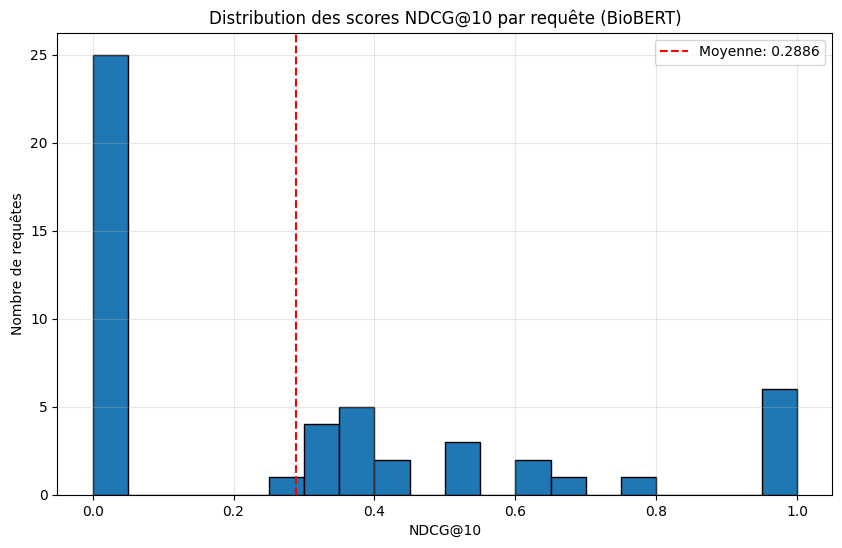

In [15]:
# Afficher la distribution des scores NDCG@10
ndcg_scores = evaluation_results['scores']

plt.figure(figsize=(10, 6))
plt.hist(list(ndcg_scores.values()), bins=20, edgecolor='black')
plt.xlabel('NDCG@10')
plt.ylabel('Nombre de requêtes')
plt.title('Distribution des scores NDCG@10 par requête (BioBERT)')
plt.axvline(evaluation_results['mean_score'], color='r', linestyle='--', 
            label=f'Moyenne: {evaluation_results["mean_score"]:.4f}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 📈 7. Analyse des Résultats


In [16]:
# Afficher les meilleures et pires requêtes
ndcg_df = pd.DataFrame([
    {'query_id': qid, 'ndcg@10': score} 
    for qid, score in ndcg_scores.items()
]).sort_values('ndcg@10', ascending=False)

print("Top 5 meilleures requêtes:")
print(ndcg_df.head())
print("\nTop 5 pires requêtes:")
print(ndcg_df.tail())


Top 5 meilleures requêtes:
   query_id  ndcg@10
26       27      1.0
27       28      1.0
35       36      1.0
45       46      1.0
44       45      1.0

Top 5 pires requêtes:
   query_id  ndcg@10
34       35      0.0
42       43      0.0
47       48      0.0
48       49      0.0
49       50      0.0


In [17]:
# Analyser une requête avec un bon score
best_query_id = ndcg_df.iloc[0]['query_id']
best_query_text = queries[best_query_id]
best_ndcg = ndcg_df.iloc[0]['ndcg@10']

print(f"\nRequête avec le meilleur NDCG@10 ({best_ndcg:.4f}):")
print(f"ID: {best_query_id}")
print(f"Texte: {best_query_text}\n")

# Obtenir les résultats du modèle pour cette requête depuis all_model_results
model_results = all_model_results[best_query_id]

print("Top 5 documents retournés:")
for i, (doc_id, score) in enumerate(model_results[:5], 1):
    doc = corpus[doc_id]
    relevance = qrels.get(best_query_id, {}).get(doc_id, 0)
    print(f"{i}. Doc {doc_id} (score BioBERT: {score:.4f}, pertinence réelle: {relevance})")
    print(f"   Titre: {doc['title'][:80]}...")
    print()



Requête avec le meilleur NDCG@10 (1.0000):
ID: 27
Texte: what is known about those infected with Covid-19 but are asymptomatic?

Top 5 documents retournés:
1. Doc 7yxz43c6 (score BioBERT: 0.9389, pertinence réelle: 1)
   Titre: What are the risks of COVID-19 infection in pregnant women?...

2. Doc uac0cfrc (score BioBERT: 0.9321, pertinence réelle: 0)
   Titre: What is the current state of knowledge about the novel coronavirus infection dur...

3. Doc epw1wt6m (score BioBERT: 0.9311, pertinence réelle: 0)
   Titre: Who is most likely to be infected with SARS-CoV-2?...

4. Doc hb2aaa29 (score BioBERT: 0.9282, pertinence réelle: 0)
   Titre: What further should be done to control COVID-19 outbreaks in addition to cases i...

5. Doc t3vea9uv (score BioBERT: 0.9267, pertinence réelle: 0)
   Titre: To what extent do children transmit SARS-CoV-2 virus?...



## 💾 8. Sauvegarde des Résultats


In [18]:
# Sauvegarder les résultats pour comparaison avec BioWord2Vec et TF-IDF
results_dir = "results"
os.makedirs(results_dir, exist_ok=True)

# Sauvegarder les scores NDCG
ndcg_scores = evaluation_results['scores']
with open(f"{results_dir}/biobert_ndcg_scores.json", "w", encoding="utf-8") as f:
    json.dump(ndcg_scores, f, indent=2)

# Sauvegarder le résumé
summary = {
    "model": "BioBERT",
    "model_name": model_name,
    "mean_ndcg@10": evaluation_results['mean_score'],
    "min_ndcg@10": evaluation_results['min_score'],
    "max_ndcg@10": evaluation_results['max_score'],
    "std_ndcg@10": evaluation_results['std_score'],
    "num_queries": evaluation_results['num_queries'],
    "num_documents": len(doc_ids),
    "embedding_dim": doc_vectors.shape[1],
    "max_length": 512
}

with open(f"{results_dir}/biobert_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

print(f"✓ Résultats sauvegardés dans {results_dir}/")
print(f"  - biobert_ndcg_scores.json")
print(f"  - biobert_summary.json")


✓ Résultats sauvegardés dans results/
  - biobert_ndcg_scores.json
  - biobert_summary.json
